# 05b · Field monitors: where they sit, what they record

Every simulation example so far showed a field map, always from the default
monitor. This notebook is about **controlling** that monitor:

- each axis in `spec.field_monitors` adds one plane normal to it — `"z"` is
  the top view, `"y"` the side view, `"x"` the cross-section;
- by default a plane sits at the **domain center** along its normal (`x`/`y`),
  or at the **average mid-plane of the device layers** (`z`);
- `spec.field_monitor_positions` pins a plane at an absolute coordinate, and
  `spec.field_monitor_wavelengths` picks what it records;
- `plot_monitor_planes(solver)` shows all of it **before anything runs**.

The device is the **Si→SiN escalator** from the cookbook — light enters in a
silicon core and couples upward into a nitride core 300 nm above it. A device
whose action happens in the *vertical* plane is exactly where monitor
placement starts to matter.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from gds_fdtd import SimulationSpec, Technology, get_solver
from gds_fdtd.lyprocessor import load_cell
from gds_fdtd.plotting import component_outlines, plot_field, plot_monitor_planes
from gds_fdtd.simprocessor import load_component_from_tech


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)


REC = _find("examples/05_fields_and_modes/recorded")

tech = Technology.from_yaml(_find("examples/tech.yaml"))
cell, layout = load_cell(str(_find("examples/10_cookbook/si_sin_escalator.gds")),
                         top_cell="si_sin_escalator")
comp = load_component_from_tech(cell=cell, tech=tech)
print(f"{comp.name}: {comp.bounds.x_span:.1f} x {comp.bounds.y_span:.1f} um, "
      f"ports {[p.name for p in comp.ports]}")

11:42:19 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

si_sin_escalator: 18.0 x 3.8 um, ports ['opt1', 'opt2']


## 1 · The default monitor lands *between* the cores

The escalator has two device layers: Si at z = 0–0.22 µm and SiN at
z = 0.3–0.7 µm. The default z-plane is the **average of the layer mid-planes**
— (0.11 + 0.5)/2 ≈ 0.3 µm — which here falls in the gap between the two
cores, where neither mode is strongest. `plot_monitor_planes` makes that
visible on the constructed solver (offline, nothing runs):

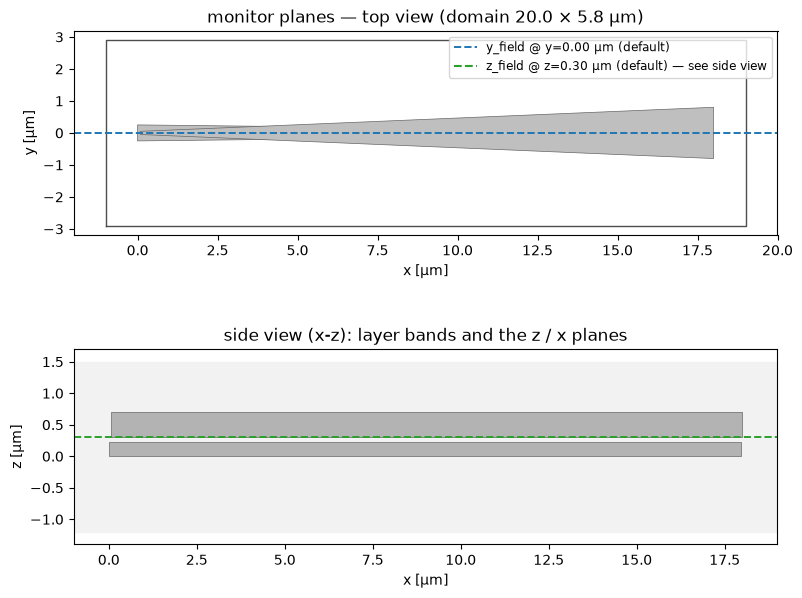

In [2]:
spec_default = SimulationSpec(
    wavelength_start=1.5, wavelength_end=1.6, wavelength_points=11,
    mesh=10, z_min=-1.2, z_max=1.5, field_monitors=("y", "z"),
)
solver_default = get_solver("tidy3d")(comp, technology=tech, spec=spec_default)
plot_monitor_planes(solver_default)
plt.show()

## 2 · Pin the plane where you want it

`field_monitor_positions` takes absolute coordinates (µm) per axis. Here the
z-plane goes to **0.11 µm — the middle of the Si core** — so the top view
shows the light where it is launched. The side (y-normal) plane keeps its
default: the domain's y-center, which is where the waveguide runs.
`field_monitor_wavelengths=(1.55,)` records a single wavelength instead of
the whole 11-point spectrum, which keeps the downloaded field data small:

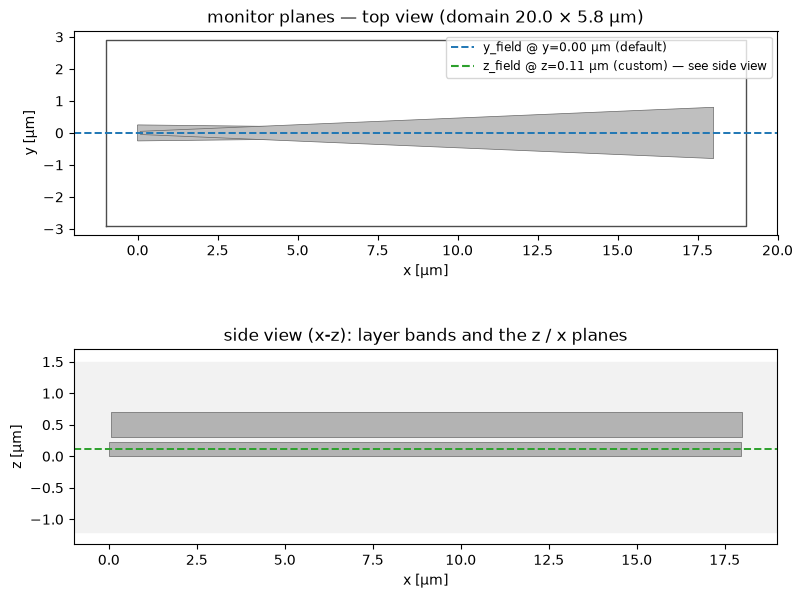

In [3]:
spec = SimulationSpec(
    wavelength_start=1.5, wavelength_end=1.6, wavelength_points=11,
    mesh=10, z_min=-1.2, z_max=1.5,
    field_monitors=("y", "z"),
    field_monitor_positions={"z": 0.11},
    field_monitor_wavelengths=(1.55,),
)
solver = get_solver("tidy3d")(comp, technology=tech, spec=spec)
plot_monitor_planes(solver)
plt.show()

The z-plane label switched from *(default)* at 0.30 µm to *(custom)* at
0.11 µm, inside the Si band of the side view.

The same solver renders as an interactive 3D scene — the two cores, the
translucent cladding, the port cones, the wireframe domain, and both
monitor planes, orbitable and clickable:

In [4]:
from gds_fdtd.viewer3d import show_3d  # noqa: E402

show_3d(solver, height=460)

## 3 · The side view: light climbing the stack

This spec ran on tidy3d (~0.05 FC; artifacts in `recorded/`, see
`PROVENANCE.md`). The y-normal monitor cuts along the propagation axis, so
it shows the vertical story: the mode enters in the Si core (z ≈ 0.1 µm),
transfers upward through the taper, and exits in the SiN core (z ≈ 0.5 µm).
The dashed outlines are the layer bands from `component_outlines(comp, "y")`:

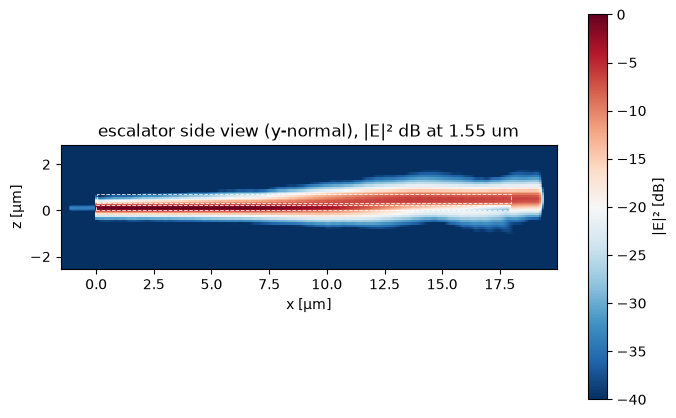

In [5]:
fy = np.load(REC / "escalator_field_y.npz")
plot_field(
    fy["mag2"][0], x=fy["h"], y=fy["v"], scale="db",
    outline=component_outlines(comp, axis="y"),
    title=f"escalator side view (y-normal), |E|² dB at {fy['wavelength_um'][0]:.2f} um",
)
plt.ylabel("z [µm]")
plt.show()

## 4 · The pinned top view: light leaving its own plane

The z-plane at the **Si core** tells the same story from above: strong field
in the input waveguide, then the intensity fades out along the taper — not
because light is lost, but because it moved up and out of this plane into
the nitride. (Re-pin the monitor at z = 0.5 µm and the picture inverts.)

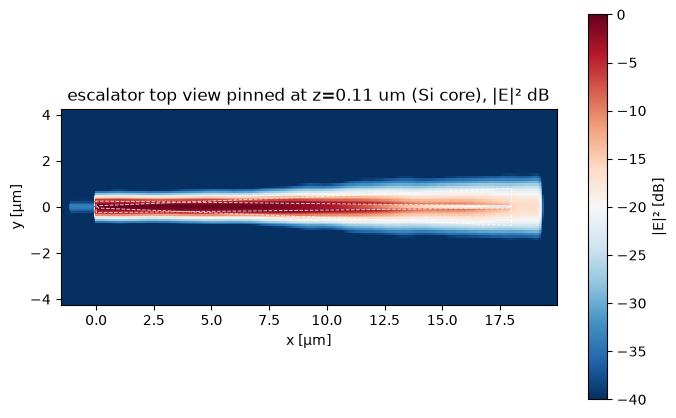

In [6]:
fz = np.load(REC / "escalator_field_z.npz")
plot_field(
    fz["mag2"][0], x=fz["h"], y=fz["v"], scale="db",
    outline=component_outlines(comp, axis="z"),
    title="escalator top view pinned at z=0.11 um (Si core), |E|² dB",
)
plt.show()

## 5 · The numbers behind the pictures

The same run produced the S-matrix; the escalator transfers the band with
low loss, confirming the field pictures:

In [7]:
from gds_fdtd.smatrix import SMatrix  # noqa: E402

sm = SMatrix.from_npz(REC / "escalator_tidy3d.npz")
thru = sm.sel(sm.port_names[1], sm.port_names[0], 1, 1)
il_db = 10 * np.log10(np.abs(thru) ** 2)
print(f"through-path insertion loss: {il_db.min():.2f} .. {il_db.max():.2f} dB "
      f"across {sm.wavelength_um.min():.2f}-{sm.wavelength_um.max():.2f} um")

through-path insertion loss: -0.07 .. -0.06 dB across 1.50-1.60 um


## Recap

- One monitor plane per axis in `spec.field_monitors`; defaults are the
  domain center (`x`/`y`) and the device layers' average mid-plane (`z`).
- `spec.field_monitor_positions` pins any plane at an absolute coordinate —
  for multi-layer stacks the default z-plane can sit between the layers, so
  pin it to the core you care about.
- `spec.field_monitor_wavelengths` restricts what is recorded; the S-matrix
  keeps its full spectral resolution independently.
- `plot_monitor_planes(solver)` shows every plane, labelled default/custom,
  before you spend anything.

`11_bragg_grating` uses the wavelength knob on a strongly dispersive device:
the same monitor, in and out of a Bragg stopband.